## Load packages

In [2]:
library("dartR")
library("ggplot2")
library("dplyr")

In [3]:
#source("outflank.rdata")

##### Outflank and Bayescan results ####
# xx haplotypes
bayescan_idx <- c()
# xx haplotypes
outflank_idx <- c()


## Running outflank

Import the data by using the genepop file

In [4]:
infile <- "../../data/YFT.snp.kinrm.pcrelate.gen"

full_dataset <- import2genind(infile, ncode = 3L)

pop_names <- c("ATL", "GOM", "IVC", "GOM", "SEN", "TX", "VZ")

## Change group labels
popNames(full_dataset) <- pop_names



 Converting data from a Genepop .gen file to a genind object... 


File description:  genepop generated from PopData by PopGen.jl 

...done.



Run OutFLANK using dartR wrapper script


Calculating FSTs, may take a few minutes...
[1] "10000 done of 15748"


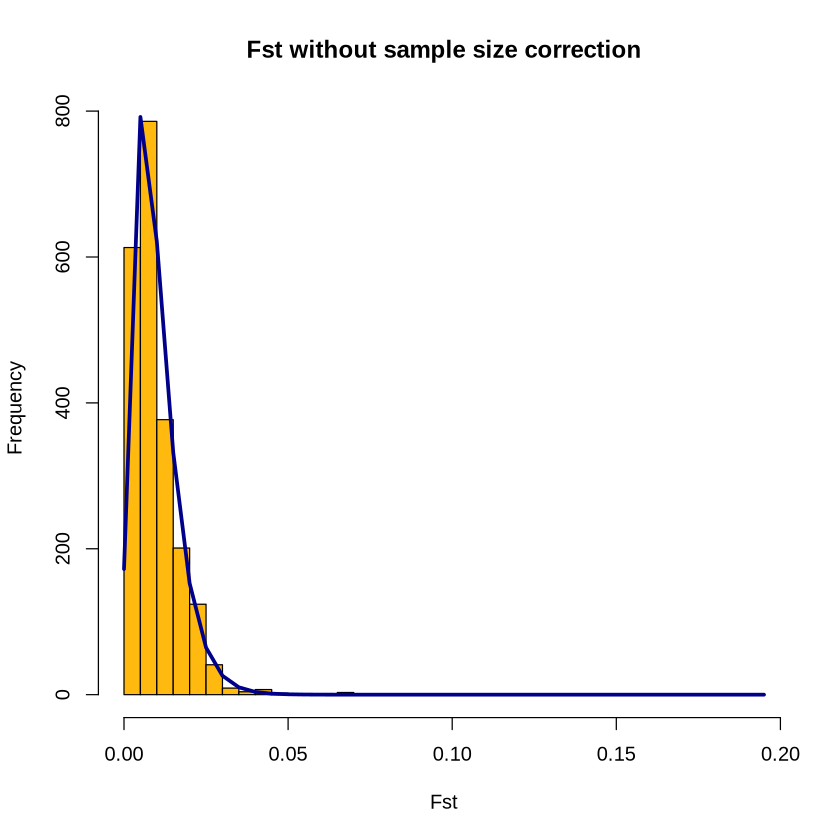

In [5]:
full_outflnk <- gl.outflank(
  full_dataset,
  Hmin = 0.1,
  qthreshold = 0.01,
  LeftTrimFraction = 0.05,
  RightTrimFraction = 0.1
)

## Processing results
## Outliers

In [6]:
full_outflnk <- full_outflnk$outflank$results


Remove duplicated rows for each SNP


In [ ]:
toRemove <- seq(1, nrow(full_outflnk), by = 2)
full_outflnk <- full_outflnk[-toRemove, ]


Check for linear conformity, remove loci that deviate substantially. Also a good time to remove NA values and assess whether it's a true outlier when its `He`terozygosity is >= 0.1.


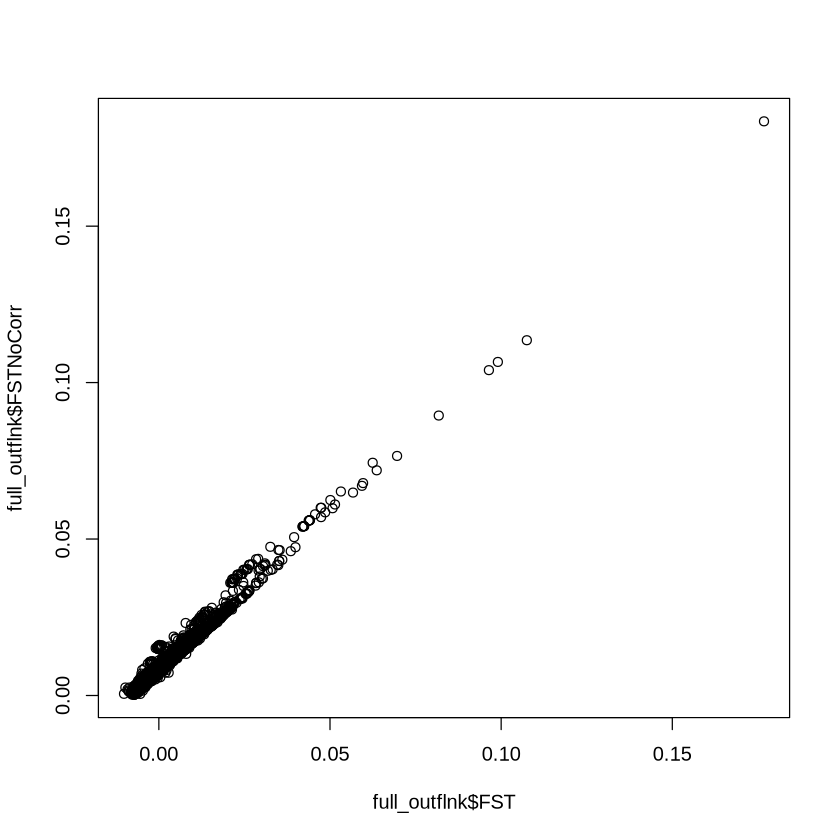

In [17]:
plot(full_outflnk$FST, full_outflnk$FSTNoCorr)

full_outflnk <- full_outflnk[!is.na(full_outflnk$He),] %>%
  mutate(
    putative = case_when(
      (He >= 0.1 & OutlierFlag == TRUE) ~ TRUE,
      (He >= 0.1 & OutlierFlag == FALSE) ~ FALSE,
      (He < 0.1) ~ FALSE
    )
  )


Saving 7 x 7 in image


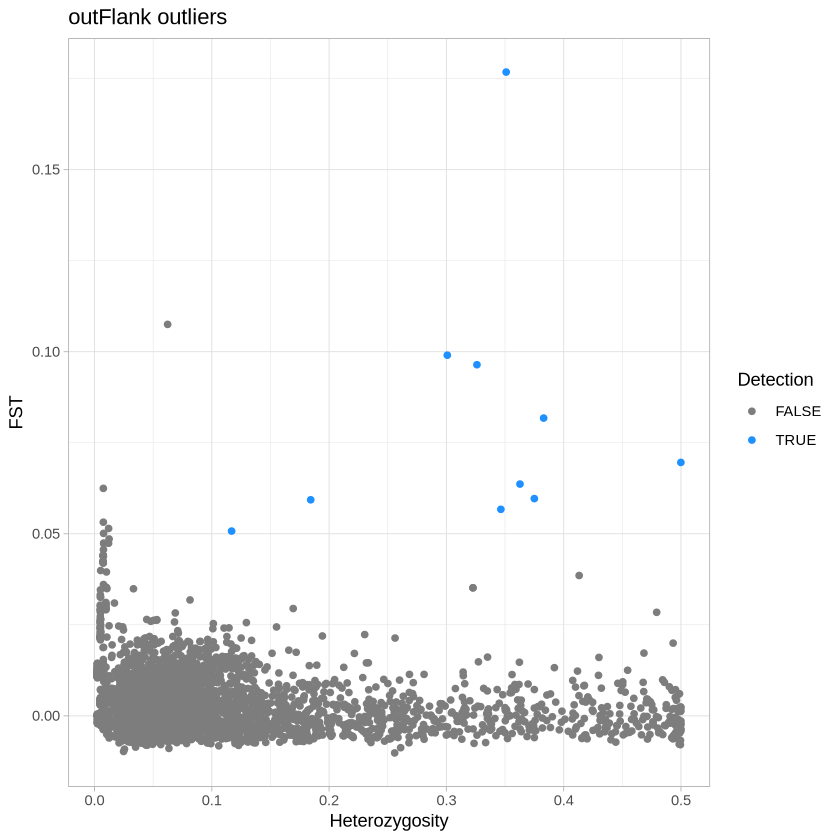

In [24]:
full_outflnk %>% 
ggplot(aes(x = He, y = FST)) + 
  geom_point(aes(color = putative)) +
  scale_color_manual(values = c("grey49", "dodgerblue")) +
  theme_light() +
  labs(title = "outFlank outliers" , x = "Heterozygosity", y = "FST", color = "Detection")

ggsave(filename = "outflank_outliers.snps.png")

pull out outliers w/ He > 0.1


In [26]:
putatives <- full_outflnk |> filter(He >= 0.1 & OutlierFlag == TRUE)
write.csv(
    putatives,
    file = "outFLANK_putatives.csv",
    row.names = FALSE,
    quote = FALSE
)


Get indexes for outliers


In [ ]:
out_index <- which(full_outflnk$OutlierFlag==TRUE)
outflank_names <- locNames(full_dataset)[out_index]
outlier_sub <- full_outflnk[out_index, ]
bayes_sub <- full_outflnk[bayescan_idx, ]


## Write output files

In [ ]:
write.csv(
  full_outflnk,
  file = "outFLANK_FST.csv",
  row.names = FALSE,
  quote = FALSE
)

full_out.outflnk <- locNames(full_dataset)[out_index]
full_out.outflnk

# output only outlier loci
write.csv(full_out.outflnk, file="outlier_outFLANK.csv", row.names = FALSE, quote = FALSE, col.names = FALSE)


[1] "snp_1103" "snp_1130" "snp_1131" "snp_1133" "snp_1134" "snp_1586"
 [7] "snp_1589" "snp_2473" "snp_3112" "snp_3602"

Warning message in write.csv(full_out.outflnk, file = "outlier_outFLANK.csv", row.names = FALSE, :
“attempt to set 'col.names' ignored”


## Figures
### qvalue hist


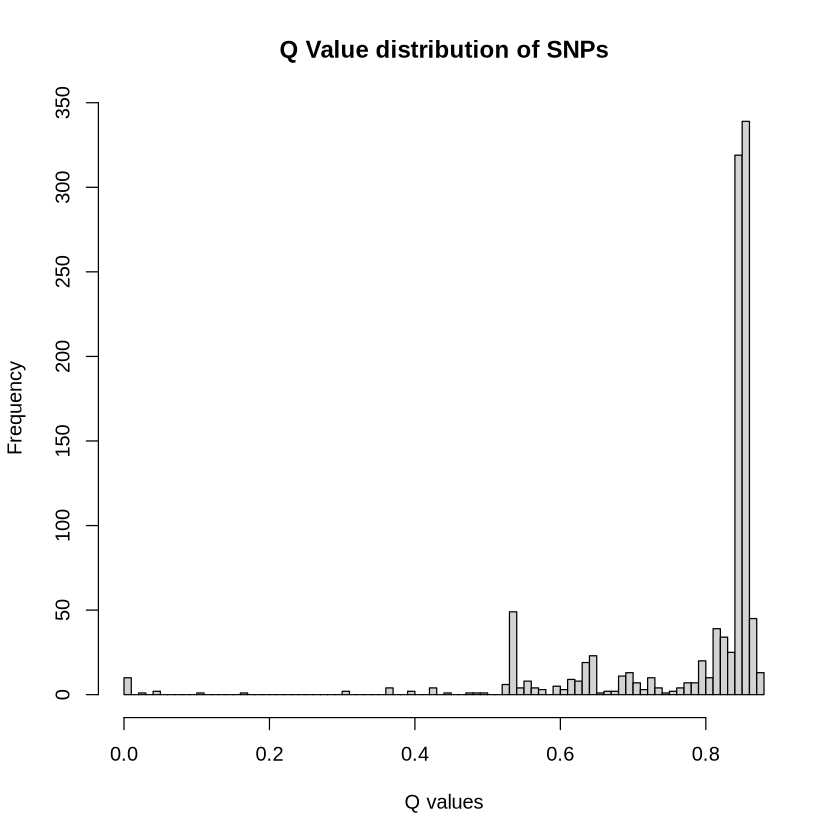

In [ ]:
hist(
  full_outflnk$qvalues,
  breaks = 100,
  xlab = "Q values",
  main = "Q Value distribution of SNPs"
)

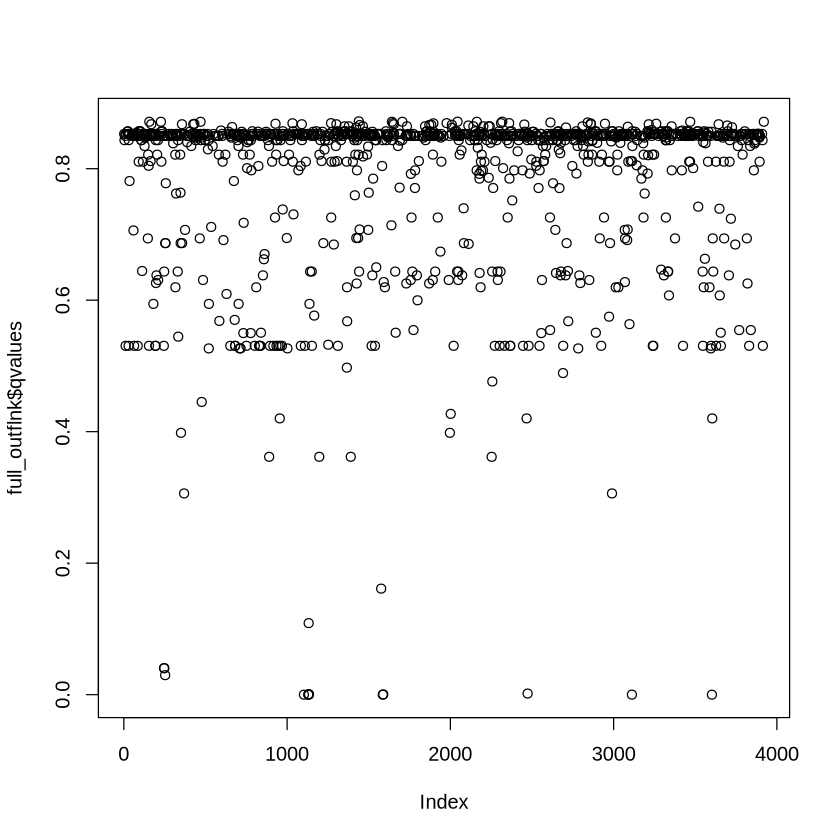

In [32]:
plot(x = full_outflnk$qvalues)

## fancy ggplot

In [ ]:
full_outflnk$outlier <- "Neither"
outlier_both <- intersect(bayescan_idx, out_index)
full_outflnk$outlier[out_index] <- "outFLANK"
bayescan_safe <- bayescan_idx[bayescan_idx <= length(full_outflnk$LocusName)]
full_outflnk$outlier[bayescan_safe] <- "BayeScan"
full_outflnk$outlier[outlier_both] <- "Both"
full_outflnk$outlier <- factor(full_outflnk$outlier, levels = c("Neither", "outFLANK", "BayeScan", "Both"), ordered = TRUE)

mycolors <- c("#bbbbbb", "#4095b5", "#8a556e", "#f4cf30")
ggplot(data = full_outflnk, x = He, y = FST) + 
  theme_classic() +
  geom_point(aes(x = He, y = FST, col = outlier), alpha = 0.8,  size = 2.1) + 
  geom_point(data = subset(full_outflnk, outlier %in% "BayeScan"), aes(x = He, y = FST), color = "#8a556e") +
  geom_vline(xintercept = 0.1, alpha = 0.8, linetype = "dashed", size = 0.3) +
  labs(x = "Heterozygosity", y = "FST", color = "Detection") +
  scale_color_manual(values = mycolors) +
  ggtitle("Outlier Loci") +
  theme(plot.title = element_text(hjust = 0.5))


bayescan_out <- locNames(full_dataset)[bayescan_idx]
outflank_out <- locNames(full_dataset)[out_index]

write.table(outflank_out, file = "outflank_outliers.txt", row.names = FALSE, col.names = FALSE, quote = FALSE)

save.image("outflank.rdata")
